# ***Bank Customer Churn Prediction***
### **3 Models : Logistic Regression - XGBoost - MLP**

---
##  **Main Steps**
- **Data Import**
- **Data Split** : Split Train/Test
- **Imbalanced DataSet Management** : SMOTE(), Scale_pos_Weight 
- **Logistic Regression** : ...
- **XGBoost** : ...
- **MultiLayer Perceptron** : ...
- **Best model selection and final prediction** :  



### Libraries

In [70]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import fbeta_score , classification_report, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, recall_score, precision_score
import matplotlib.pyplot as plt


In [18]:
import warnings
warnings.filterwarnings('ignore')

### **1. Dataframes Import**
The datasets imported in this notebook have already been through data cleaning, preprocessing, handling of missing values, and feature engineering steps - ref. `1_BankCustomersChurn_DataPrep`.

#### 1.1. Import DataSet for XGBoost & MLP

In [19]:
df = pd.read_csv('BankCustomersSet_XGBoost_MLP.csv', sep = ',')
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Balance_Is_Zero,Balance_Salary_Ratio,IsActive_x_NumProducts,Tenure_Per_Age
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0,1,0.000000,1,0.046512
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1,0,0.744670,1,0.023810
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0,0,1.401362,0,0.186047
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0,1,0.000000,0,0.025000
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1,0,1.587035,1,0.045455


In [20]:
df.info() 
# All features are numeric

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CreditScore             10000 non-null  int64  
 1   Gender                  10000 non-null  int64  
 2   Age                     10000 non-null  int64  
 3   Tenure                  10000 non-null  int64  
 4   Balance                 10000 non-null  float64
 5   NumOfProducts           10000 non-null  int64  
 6   HasCrCard               10000 non-null  int64  
 7   IsActiveMember          10000 non-null  int64  
 8   EstimatedSalary         10000 non-null  float64
 9   Exited                  10000 non-null  int64  
 10  Geography_Germany       10000 non-null  int64  
 11  Geography_Spain         10000 non-null  int64  
 12  Balance_Is_Zero         10000 non-null  int64  
 13  Balance_Salary_Ratio    10000 non-null  float64
 14  IsActive_x_NumProducts  10000 non-null  int64  
 1

#### 1.2. Import DataSet for Logistic Regression

In [21]:
df_lr = pd.read_csv('BankCustomersSet_LR.csv', sep = ',')
df_lr.head()

,CreditScore,Gender,NumOfProducts,HasCrCard,EstimatedSalary,Exited,Geography_Spain,Balance_Is_Zero,Balance_Salary_Ratio,IsActive_x_NumProducts,Tenure_Per_Age,Age_Squared,Germany_x_Balance
0,619,0,1,1,101348.88,1,0,1,0.000000,1,0.046512,1764,0.0
1,608,0,1,0,112542.58,0,1,0,0.744670,1,0.023810,1681,0.0
2,502,0,3,1,113931.57,1,0,0,1.401362,0,0.186047,1764,0.0
3,699,0,2,0,93826.63,0,0,1,0.000000,0,0.025000,1521,0.0
4,850,0,1,1,79084.10,0,1,0,1.587035,1,0.045455,1849,0.0


In [22]:
df_lr.info() 
# All features are numeric

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CreditScore             10000 non-null  int64  
 1   Gender                  10000 non-null  int64  
 2   NumOfProducts           10000 non-null  int64  
 3   HasCrCard               10000 non-null  int64  
 4   EstimatedSalary         10000 non-null  float64
 5   Exited                  10000 non-null  int64  
 6   Geography_Spain         10000 non-null  int64  
 7   Balance_Is_Zero         10000 non-null  int64  
 8   Balance_Salary_Ratio    10000 non-null  float64
 9   IsActive_x_NumProducts  10000 non-null  int64  
 10  Tenure_Per_Age          10000 non-null  float64
 11  Age_Squared             10000 non-null  int64  
 12  Germany_x_Balance       10000 non-null  float64
dtypes: float64(4), int64(9)
memory usage: 1015.8 KB


---
### **2. Split Train/Test**

In [23]:
# Split data for XGBoost and MLP
X = df.drop('Exited', axis = 1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# -------------------------------------------------------------------------------------------------------
# Split data for Logistic Regression
X_lr = df_lr.drop('Exited', axis=1)
y_lr = df_lr['Exited']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr)


print(f"Train size : {X_train.shape[0]} | Test size : {X_test.shape[0]}")
print(f"Churn rate train : {y_train.mean():.2%} | Churn rate test : {y_test.mean():.2%}")

print(f"\nTrain size (LR) : {X_train_lr.shape[0]} | Test size (LR) : {X_test_lr.shape[0]}")
print(f"Churn rate train (LR) : {y_train_lr.mean():.2%} | Churn rate test (LR) : {y_test_lr.mean():.2%}")


Train size : 8000 | Test size : 2000
Churn rate train : 20.38% | Churn rate test : 20.35%

Train size (LR) : 8000 | Test size (LR) : 2000
Churn rate train (LR) : 20.38% | Churn rate test (LR) : 20.35%


---
### **3. Imbalanced DataSet Management** 

#### 3.1 `SMOTE()` for LR & MLP
When the dataset is imbalanced, models like LR and MLP tend to be biased toward the majority class. **SMOTE** artificially generates synthetic samples of the minority class in the training set, forcing the model to learn from a balanced distribution.

In [24]:
smote = SMOTE(random_state=42)

X_train_lr_res, y_train_lr_res = smote.fit_resample(X_train_lr, y_train_lr)
X_train_res, y_train_res       = smote.fit_resample(X_train, y_train)

print(f"LR  - Après SMOTE : {y_train_lr_res.value_counts().to_dict()}")
print(f"MLP - Après SMOTE : {y_train_res.value_counts().to_dict()}")

LR  - Après SMOTE : {1: 6370, 0: 6370}
MLP - Après SMOTE : {1: 6370, 0: 6370}


#### 3.2. `scale_pos_weight` for XGBoost
XGBoost natively supports class imbalance through the `scale_pos_weight` parameter, which assigns a higher weight to the minority class during training. This adjusts the loss function directly, penalizing misclassifications of the minority class more heavily without requiring any resampling of the data.

In [25]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Scale pos weight (XGBoost) : {scale_pos_weight:.2f}")

Scale pos weight (XGBoost) : 3.91


---
### **4. Build a Logistic Regression Model**

#### 4.1. Pipeline Construction
Logistic Regression is sensitive to feature scale. A `StandardScaler` is embedded inside a `Pipeline` to ensure that scaling is fitted **only on the training data**, preventing any information leakage from the test set.

In [27]:
# Scale data for LR
# Using a pipeline guarantees the scaler is never fitted on test data
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

#### 4.2. Hyperparameter Tuning — `GridSearchCV`
The search space explores two regularisation types (`L1`, `L2`) and six values of `C` (regularisation strength). `liblinear` is chosen as solver since it supports both penalties and is efficient on small-to-medium datasets.

The scoring metric is **ROC-AUC** to account for the class imbalance context.


In [ ]:
# C controls regularisation strength (inverse):
#   - small C → strong regularisation → simpler model (risk of underfitting)
#   - large C → weak regularisation  → complex model (risk of overfitting)
# L1 induces sparsity (implicit feature selection), L2 shrinks coefficients

param_grid_lr = {
    'lr__C':            [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty':      ['l1', 'l2'],
    'lr__solver':       ['liblinear'],
    'lr__class_weight': [None, 'balanced']  
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    scoring   = 'roc_auc',
    cv        = 5,
    n_jobs    = -1,
    verbose   = 1,
    return_train_score = True
)

grid_lr.fit(X_train_lr_res, y_train_lr_res)

print(f"Best params  : {grid_lr.best_params_}")
print(f"Best CV ROC-AUC : {grid_lr.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params  : {'lr__C': 0.01, 'lr__class_weight': None, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best CV ROC-AUC : 0.8388


#### 4.3. Regularisation Curve
The regularisation curve shows how the train and validation ROC-AUC evolve as `C` increases, making underfitting and overfitting regions clearly visible.


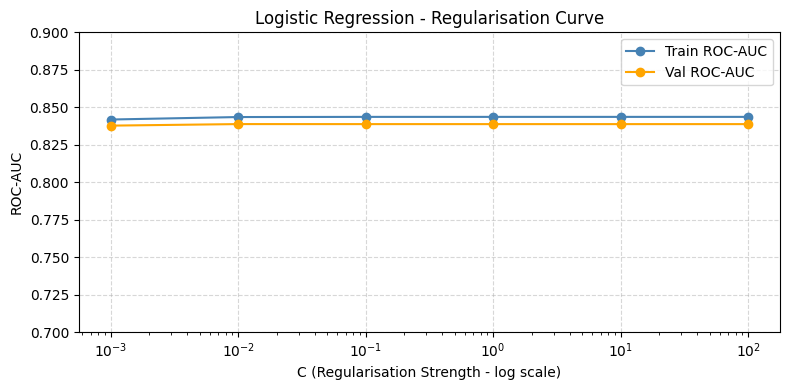

In [61]:
results_lr = pd.DataFrame(grid_lr.cv_results_)

# Filter to the best penalty and class_weight found above
best_penalty = grid_lr.best_params_['lr__penalty']
best_cw      = grid_lr.best_params_['lr__class_weight']

# pandas cannot compare None with ==, we use isna() in that case
if best_cw is None:
    mask_cw = results_lr['param_lr__class_weight'].isna()
else:
    mask_cw = results_lr['param_lr__class_weight'] == best_cw

mask = (results_lr['param_lr__penalty'] == best_penalty) & mask_cw

res_filtered = results_lr[mask].sort_values('param_lr__C')
C_values     = res_filtered['param_lr__C'].astype(float)
mean_train   = res_filtered['mean_train_score']
mean_val     = res_filtered['mean_test_score']


# Plot regularisation curve
plt.figure(figsize=(8, 4))
plt.plot(C_values, mean_train, marker='o', label='Train ROC-AUC', color='steelblue')
plt.plot(C_values, mean_val,   marker='o', label='Val ROC-AUC',   color='orange')
plt.xscale('log')
plt.ylim(0.7, 0.9)
plt.xlabel('C (Regularisation Strength - log scale)')
plt.ylabel('ROC-AUC')
plt.title('Logistic Regression - Regularisation Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**KEY INSIGHTS**  
The ROC-AUC scores remain stable across all values of the regularization parameter `C`, indicating that the model **is not sensitive to regularization changes**. The very small gap between training and validation scores suggests good generalization with no significant overfitting.


#### 4.4. Best Model


In [38]:
best_lr = grid_lr.best_estimator_

# Extract the fitted LR step from the pipeline for coefficient inspection
lr_model = best_lr.named_steps['lr']

print(f"Best estimator : {best_lr}")

Best estimator : Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.01, max_iter=1000, penalty='l2',
                                    random_state=42, solver='liblinear'))])


#### 4.5. Threshold Optimisation
The default threshold of `0.5` is designed for balanced datasets. In a churn context, **missing a churner (false negative) is more costly** than a false alarm (false positive). We select the threshold that maximises the **F2-score**, which weights recall twice as much as precision.


Optimal threshold (F2) : 0.2784
Best F2-score at threshold : 0.6108


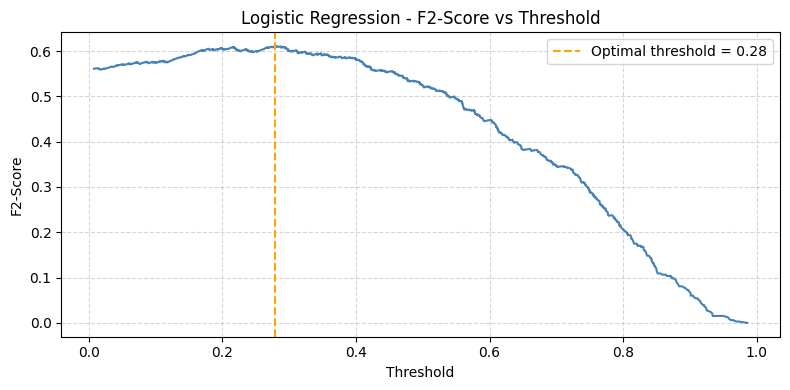

In [40]:
y_proba_lr = best_lr.predict_proba(X_test_lr)[:, 1]

precisions_lr, recalls_lr, thresholds_lr = precision_recall_curve(y_test_lr, y_proba_lr)

# F2 = (5 * P * R) / (4 * P + R)  →  beta=2 emphasises recall
f2_scores_lr = (5 * precisions_lr[:-1] * recalls_lr[:-1]) / \
               (4 * precisions_lr[:-1] + recalls_lr[:-1] + 1e-8)

best_threshold_lr = thresholds_lr[np.argmax(f2_scores_lr)]

print(f"Optimal threshold (F2) : {best_threshold_lr:.4f}")
print(f"Best F2-score at threshold : {f2_scores_lr.max():.4f}")

# ---------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(thresholds_lr, f2_scores_lr, color='steelblue')
plt.axvline(best_threshold_lr, color='orange', linestyle='--',
            label=f'Optimal threshold = {best_threshold_lr:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F2-Score')
plt.title('Logistic Regression - F2-Score vs Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 4.6. Predictions & Evaluation


In [41]:
# Apply optimal threshold instead of default 0.5
y_pred_lr = (y_proba_lr >= best_threshold_lr).astype(int)

# -- Classification Report --------------------------------
print("Classification Report — Logistic Regression\n")
print(classification_report(y_test_lr, y_pred_lr, target_names=['No Churn', 'Churn']))

# -- Metrics Summary --------------------------------------
roc_auc_lr = roc_auc_score(y_test_lr, y_proba_lr)
pr_auc_lr  = average_precision_score(y_test_lr, y_proba_lr)
f2_lr      = fbeta_score(y_test_lr, y_pred_lr, beta=2)

print(f"ROC-AUC  : {roc_auc_lr:.4f}")
print(f"PR-AUC   : {pr_auc_lr:.4f}")
print(f"F2-Score : {f2_lr:.4f}")

Classification Report — Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.92      0.50      0.65      1593
       Churn       0.30      0.83      0.44       407

    accuracy                           0.56      2000
   macro avg       0.61      0.66      0.54      2000
weighted avg       0.79      0.56      0.60      2000

ROC-AUC  : 0.7283
PR-AUC   : 0.4041
F2-Score : 0.6108


**KEY INSIGHTS**


---
### **5. Build a XGBoost Model**

#### 5.1. Hyperparameter Tuning with `RandomizedSearchCV`
XGBoost's hyperparameter space is too large for a full grid search. `RandomizedSearchCV` samples `n_iter` random combinations, offering a good coverage of the space at a fraction of the computational cost.

`scale_pos_weight` (computed in section 3.2) is kept fixed: it is not a model hyperparameter to tune but a dataset-driven correction for class imbalance.


In [ ]:
param_dist_xgb = {
    'n_estimators':     [100, 300, 500],       
    'max_depth':        [3, 5, 7, 9],      
    'learning_rate':    [0.01, 0.05, 0.1, 0.3], 
    'subsample':        [0.6, 0.8, 1.0],  
    'colsample_bytree': [0.6, 0.8, 1.0],  
    'min_child_weight': [1, 3, 5],       
    'gamma':            [0, 0.1, 0.3]  
}      

xgb_base = XGBClassifier(
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42,
    use_label_encoder = False
)

rand_xgb = RandomizedSearchCV(
    xgb_base,
    param_dist_xgb,
    n_iter    = 50,
    scoring   = 'roc_auc',
    cv        = 5,
    n_jobs    = -1,
    verbose   = 1,
    random_state = 42,
    return_train_score = True
)

rand_xgb.fit(X_train, y_train)

print(f"Best params  : {rand_xgb.best_params_}")
print(f"Best CV ROC-AUC : {rand_xgb.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params  : {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}
Best CV ROC-AUC : 0.8653


#### 5.2. Loss Curve - Train vs Validation
We re-train the best estimator with `eval_set` to record the **log-loss at each boosting round**. This is XGBoost's native equivalent of a neural network loss curve and directly reveals overfitting behaviour.


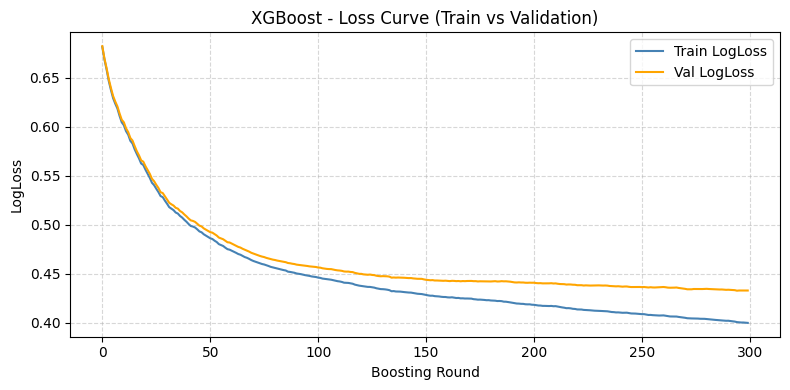

In [63]:
# Re-train best estimator with eval_set to capture loss per boosting round
best_params_xgb = rand_xgb.best_params_.copy()

best_xgb_curve = XGBClassifier(
    **best_params_xgb,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = 'logloss',
    random_state      = 42,
    use_label_encoder = False
)

best_xgb_curve.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_test, y_test)],
    verbose  = False
)

evals_result  = best_xgb_curve.evals_result()
train_logloss = evals_result['validation_0']['logloss']
val_logloss   = evals_result['validation_1']['logloss']

plt.figure(figsize=(8, 4))
plt.plot(train_logloss, label='Train LogLoss', color='steelblue')
plt.plot(val_logloss,   label='Val LogLoss',   color='orange')
plt.xlabel('Boosting Round')
plt.ylabel('LogLoss')
plt.title('XGBoost - Loss Curve (Train vs Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**KEY INSIGHTS**  
- If both curves decrease and converge, the model is learning correctly.  
- A growing gap between train and validation loss signals **overfitting** — stronger regularisation (`gamma`, lower `max_depth`) or fewer rounds should be considered.  
- A flat validation curve from early rounds indicates **underfitting** — a higher `learning_rate` or more estimators may help.


#### 5.3. Best Model


In [46]:
best_xgb = rand_xgb.best_estimator_
print(f"Best estimator : {best_xgb}")

Best estimator : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


#### 5.5. Threshold Optimisation
Same approach as Logistic Regression: the threshold maximising the **F2-score** is selected on the test set.


Optimal threshold (F2) : 0.3650
Best F2-score at threshold : 0.7074


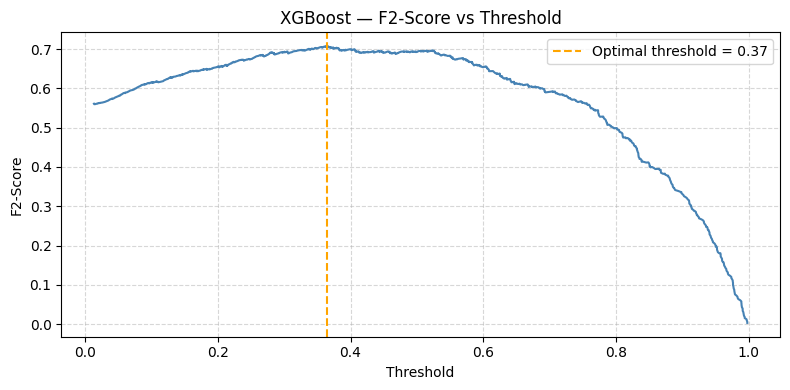

In [ ]:
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)

f2_scores_xgb = (5 * precisions_xgb[:-1] * recalls_xgb[:-1]) / \
                (4 * precisions_xgb[:-1] + recalls_xgb[:-1] + 1e-8)

best_threshold_xgb = thresholds_xgb[np.argmax(f2_scores_xgb)]

print(f"Optimal threshold (F2) : {best_threshold_xgb:.4f}")
print(f"Best F2-score at threshold : {f2_scores_xgb.max():.4f}")


plt.figure(figsize=(8, 4))
plt.plot(thresholds_xgb, f2_scores_xgb, color='steelblue')
plt.axvline(best_threshold_xgb, color='orange', linestyle='--',
            label=f'Optimal threshold = {best_threshold_xgb:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F2-Score')
plt.title('XGBoost — F2-Score vs Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 5.6. Predictions & Evaluation


In [ ]:
y_pred_xgb = (y_proba_xgb >= best_threshold_xgb).astype(int)

# Classification Report
print("Classification Report - XGBoost\n")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

# Metrics Summary
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
pr_auc_xgb  = average_precision_score(y_test, y_proba_xgb)
f2_xgb      = fbeta_score(y_test, y_pred_xgb, beta=2)

print(f"ROC-AUC  : {roc_auc_xgb:.4f}")
print(f"PR-AUC   : {pr_auc_xgb:.4f}")
print(f"F2-Score : {f2_xgb:.4f}")

Classification Report - XGBoost

              precision    recall  f1-score   support

    No Churn       0.95      0.68      0.79      1593
       Churn       0.41      0.86      0.56       407

    accuracy                           0.72      2000
   macro avg       0.68      0.77      0.67      2000
weighted avg       0.84      0.72      0.75      2000

ROC-AUC  : 0.8675
PR-AUC   : 0.7163
F2-Score : 0.7074


### **6. Build a MultiLayer Perceptron Model**

#### 6.1. Pipeline Construction
MLP is scale-sensitive in the same way as LR. A `StandardScaler` is embedded inside a `Pipeline` to ensure that scaling is fitted **only on the training data**, preventing any information leakage from the test set.

In [55]:
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, early_stopping=True, validation_fraction=0.1))
])

#### 6.2. Hyperparameter Tuning — `RandomizedSearchCV`
MLP's hyperparameter space is too large for a full grid search. `RandomizedSearchCV` samples `n_iter` random combinations, offering a good coverage of the space at a fraction of the computational cost.

In [56]:
param_dist_mlp = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'mlp__activation':         ['relu', 'tanh'],
    'mlp__alpha':              [0.0001, 0.001, 0.01, 0.1],   # L2 regularisation
    'mlp__learning_rate_init': [0.001, 0.01, 0.1],
    'mlp__batch_size':         [32, 64, 128],
    'mlp__max_iter':           [200, 500]
}

rand_mlp = RandomizedSearchCV(
    pipeline_mlp,
    param_dist_mlp,
    n_iter    = 30,
    scoring   = 'roc_auc',
    cv        = 5,
    n_jobs    = -1,
    verbose   = 1,
    random_state = 42,
    return_train_score = True
)

rand_mlp.fit(X_train_res, y_train_res)

print(f"Best params     : {rand_mlp.best_params_}")
print(f"Best CV ROC-AUC : {rand_mlp.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params     : {'mlp__max_iter': 500, 'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (64,), 'mlp__batch_size': 64, 'mlp__alpha': 0.0001, 'mlp__activation': 'relu'}
Best CV ROC-AUC : 0.9321


#### 6.3. Loss Curve - Train vs Validation
**MLPClassifier** natively exposes `loss_curve_` (train) and `validation_scores_` (val) when `early_stopping=True`. We retrain the best estimator on its own to access these attributes.

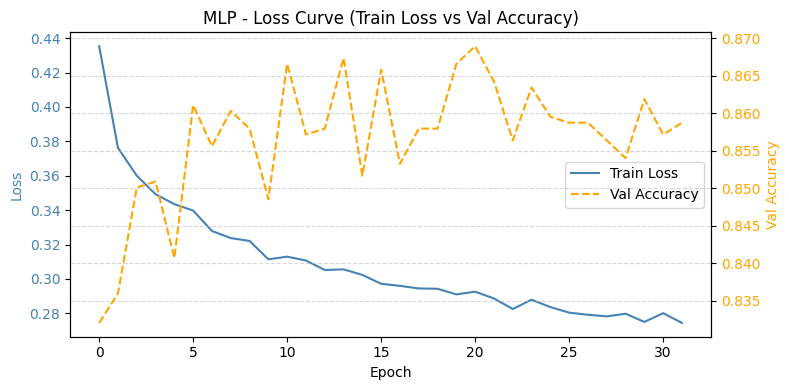

In [59]:
best_params_mlp = rand_mlp.best_params_

# Re-train best estimator standalone to access loss_curve_ and validation_scores_
best_mlp_curve = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes = best_params_mlp['mlp__hidden_layer_sizes'],
        activation         = best_params_mlp['mlp__activation'],
        alpha              = best_params_mlp['mlp__alpha'],
        learning_rate_init = best_params_mlp['mlp__learning_rate_init'],
        batch_size         = best_params_mlp['mlp__batch_size'],
        max_iter           = best_params_mlp['mlp__max_iter'],
        early_stopping     = True,
        validation_fraction = 0.1,
        random_state       = 42
    ))
])

best_mlp_curve.fit(X_train_res, y_train_res)

mlp_step       = best_mlp_curve.named_steps['mlp']
train_loss     = mlp_step.loss_curve_
val_scores     = mlp_step.validation_scores_   # accuracy on val fraction

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(train_loss, label='Train Loss',     color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(val_scores, label='Val Accuracy', color='orange', linestyle='--')
ax2.set_ylabel('Val Accuracy', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('MLP - Loss Curve (Train Loss vs Val Accuracy)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**KEY INSIGHTS**

#### 6.4. Best Model 

In [64]:
best_mlp = rand_mlp.best_estimator_
print(f"Best estimator : {best_mlp}")

Best estimator : Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(batch_size=64, early_stopping=True,
                               hidden_layer_sizes=(64,),
                               learning_rate_init=0.01, max_iter=500,
                               random_state=42))])


#### 6.5. Threshold Optimisation

Optimal threshold (F2) : 0.1880
Best F2-score at threshold : 0.6678


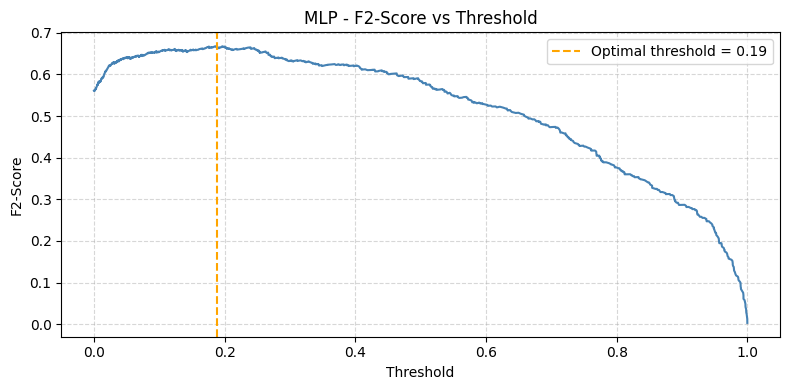

In [68]:
y_proba_mlp = best_mlp.predict_proba(X_test)[:, 1]

precisions_mlp, recalls_mlp, thresholds_mlp = precision_recall_curve(y_test, y_proba_mlp)

f2_scores_mlp = (5 * precisions_mlp[:-1] * recalls_mlp[:-1]) / \
                (4 * precisions_mlp[:-1] + recalls_mlp[:-1] + 1e-8)

best_threshold_mlp = thresholds_mlp[np.argmax(f2_scores_mlp)]

print(f"Optimal threshold (F2) : {best_threshold_mlp:.4f}")
print(f"Best F2-score at threshold : {f2_scores_mlp.max():.4f}")


plt.figure(figsize=(8, 4))
plt.plot(thresholds_mlp, f2_scores_mlp, color='steelblue')
plt.axvline(best_threshold_mlp, color='orange', linestyle='--',
            label=f'Optimal threshold = {best_threshold_mlp:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F2-Score')
plt.title('MLP - F2-Score vs Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 6.6. Predictions & Evaluation

In [66]:
y_pred_mlp = (y_proba_mlp >= best_threshold_mlp).astype(int)

# Classification Report
print("Classification Report — MLP\n")
print(classification_report(y_test, y_pred_mlp, target_names=['No Churn', 'Churn']))

# Metrics Summary
roc_auc_mlp = roc_auc_score(y_test, y_proba_mlp)
pr_auc_mlp  = average_precision_score(y_test, y_proba_mlp)
f2_mlp      = fbeta_score(y_test, y_pred_mlp, beta=2)

print(f"ROC-AUC  : {roc_auc_mlp:.4f}")
print(f"PR-AUC   : {pr_auc_mlp:.4f}")
print(f"F2-Score : {f2_mlp:.4f}")

Classification Report — MLP

              precision    recall  f1-score   support

    No Churn       0.93      0.72      0.81      1593
       Churn       0.42      0.79      0.54       407

    accuracy                           0.73      2000
   macro avg       0.67      0.75      0.68      2000
weighted avg       0.83      0.73      0.76      2000

ROC-AUC  : 0.8276
PR-AUC   : 0.6463
F2-Score : 0.6678


### **7. Best Model Selection & Final Prediction**

#### 7.1. Metrics Comparison Table
All models are evaluated on the same metrics to ensure a fair comparison. **PR-AUC** is the primary reference metric in an imbalanced setting as it focuses on the minority class (churners), unlike ROC-AUC which can be misleadingly high when negatives dominate.


In [ ]:
metrics_df = pd.DataFrame({
    'Model':     ['Logistic Regression', 'XGBoost', 'MLP'],
    'ROC-AUC':   [round(roc_auc_lr,  4), round(roc_auc_xgb,  4), round(roc_auc_mlp,  4)],
    'PR-AUC':    [round(pr_auc_lr,   4), round(pr_auc_xgb,   4), round(pr_auc_mlp,   4)],
    'F2-Score':  [round(f2_lr,       4), round(f2_xgb,       4), round(f2_mlp,       4)],
    'Recall':    [
        round(recall_score(y_test_lr, y_pred_lr),  4),
        round(recall_score(y_test,    y_pred_xgb), 4),
        round(recall_score(y_test,    y_pred_mlp), 4)
    ],
    'Precision': [
        round(precision_score(y_test_lr, y_pred_lr),  4),
        round(precision_score(y_test,    y_pred_xgb), 4),
        round(precision_score(y_test,    y_pred_mlp), 4)
    ]
})

metrics_df.set_index('Model', inplace=True)
metrics_df

,ROC-AUC,PR-AUC,F2-Score,Recall,Precision
Model,,,,,
Logistic Regression,0.7283,0.4041,0.6108,0.8305,0.2968
XGBoost,0.8675,0.7163,0.7074,0.8649,0.4093
MLP,0.8276,0.6463,0.6678,0.7862,0.4167


#### 7.2. ROC Curves Overlay


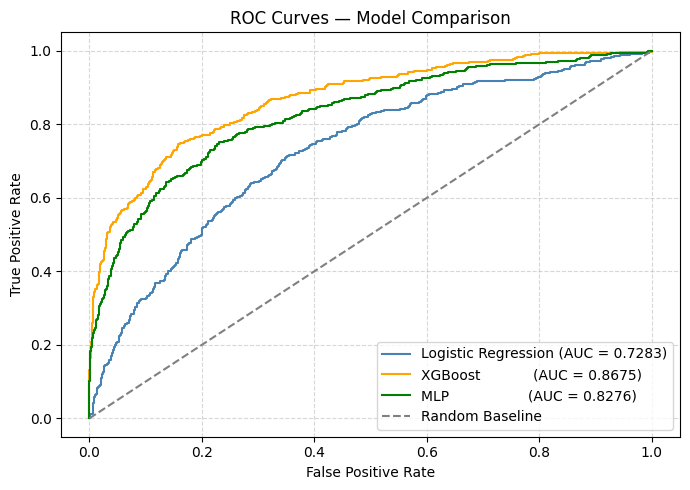

In [71]:
fpr_lr,  tpr_lr,  _ = roc_curve(y_test_lr, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})',  color='steelblue')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost            (AUC = {roc_auc_xgb:.4f})', color='orange')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP                  (AUC = {roc_auc_mlp:.4f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 7.3. Precision-Recall Curves Overlay
On imbalanced datasets, the **Precision-Recall curve** is more informative than the ROC curve. A high ROC-AUC can be achieved even with poor performance on the minority class, whereas PR-AUC directly measures quality on the churner class.


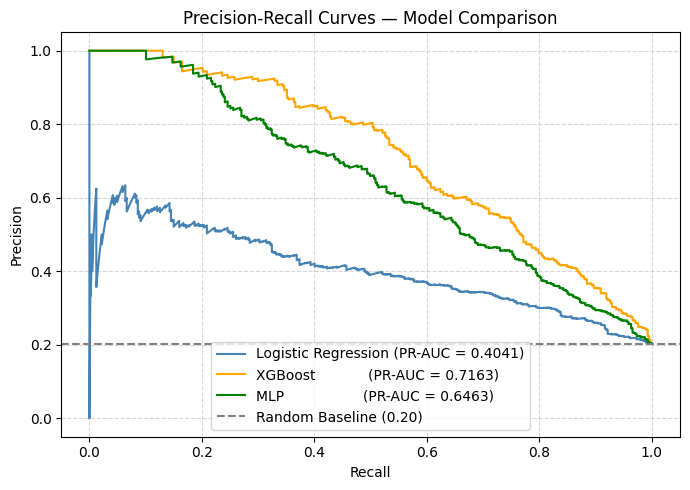

In [72]:
plt.figure(figsize=(7, 5))
plt.plot(recalls_lr,  precisions_lr,  label=f'Logistic Regression (PR-AUC = {pr_auc_lr:.4f})',  color='steelblue')
plt.plot(recalls_xgb, precisions_xgb, label=f'XGBoost            (PR-AUC = {pr_auc_xgb:.4f})', color='orange')
plt.plot(recalls_mlp, precisions_mlp, label=f'MLP                  (PR-AUC = {pr_auc_mlp:.4f})', color='green')
baseline = y_test.mean()
plt.axhline(baseline, linestyle='--', color='grey', label=f'Random Baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Model Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 7.4. Best Model Selection & Final Prediction
The best model is selected based on **PR-AUC** as the primary criterion, complemented by **F2-score** to ensure sufficient recall on the churner class.


In [73]:
# Select the model with the highest PR-AUC
best_model_name = metrics_df['PR-AUC'].idxmax()
print(f"Best model : {best_model_name}")
print(metrics_df.loc[best_model_name])

Best model : XGBoost
ROC-AUC      0.8675
PR-AUC       0.7163
F2-Score     0.7074
Recall       0.8649
Precision    0.4093
Name: XGBoost, dtype: float64


In [74]:
# Assign the winning model and its corresponding test set
if best_model_name == 'XGBoost':
    final_model     = best_xgb
    X_final_test    = X_test
    y_final_test    = y_test
    y_final_proba   = y_proba_xgb
    final_threshold = best_threshold_xgb
else:
    final_model     = best_lr
    X_final_test    = X_test_lr
    y_final_test    = y_test_lr
    y_final_proba   = y_proba_lr
    final_threshold = best_threshold_lr

# Final predictions using the optimal threshold
y_final_pred = (y_final_proba >= final_threshold).astype(int)

print(f"\nFinal Classification Report — {best_model_name}\n")
print(classification_report(y_final_test, y_final_pred, target_names=['No Churn', 'Churn']))


Final Classification Report — XGBoost

              precision    recall  f1-score   support

    No Churn       0.95      0.68      0.79      1593
       Churn       0.41      0.86      0.56       407

    accuracy                           0.72      2000
   macro avg       0.68      0.77      0.67      2000
weighted avg       0.84      0.72      0.75      2000

